# Importing libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

df = pd.read_csv('paper_leaks_cleaned.csv')
df['date'] = pd.to_datetime(df['date'])

# 01. Timeline

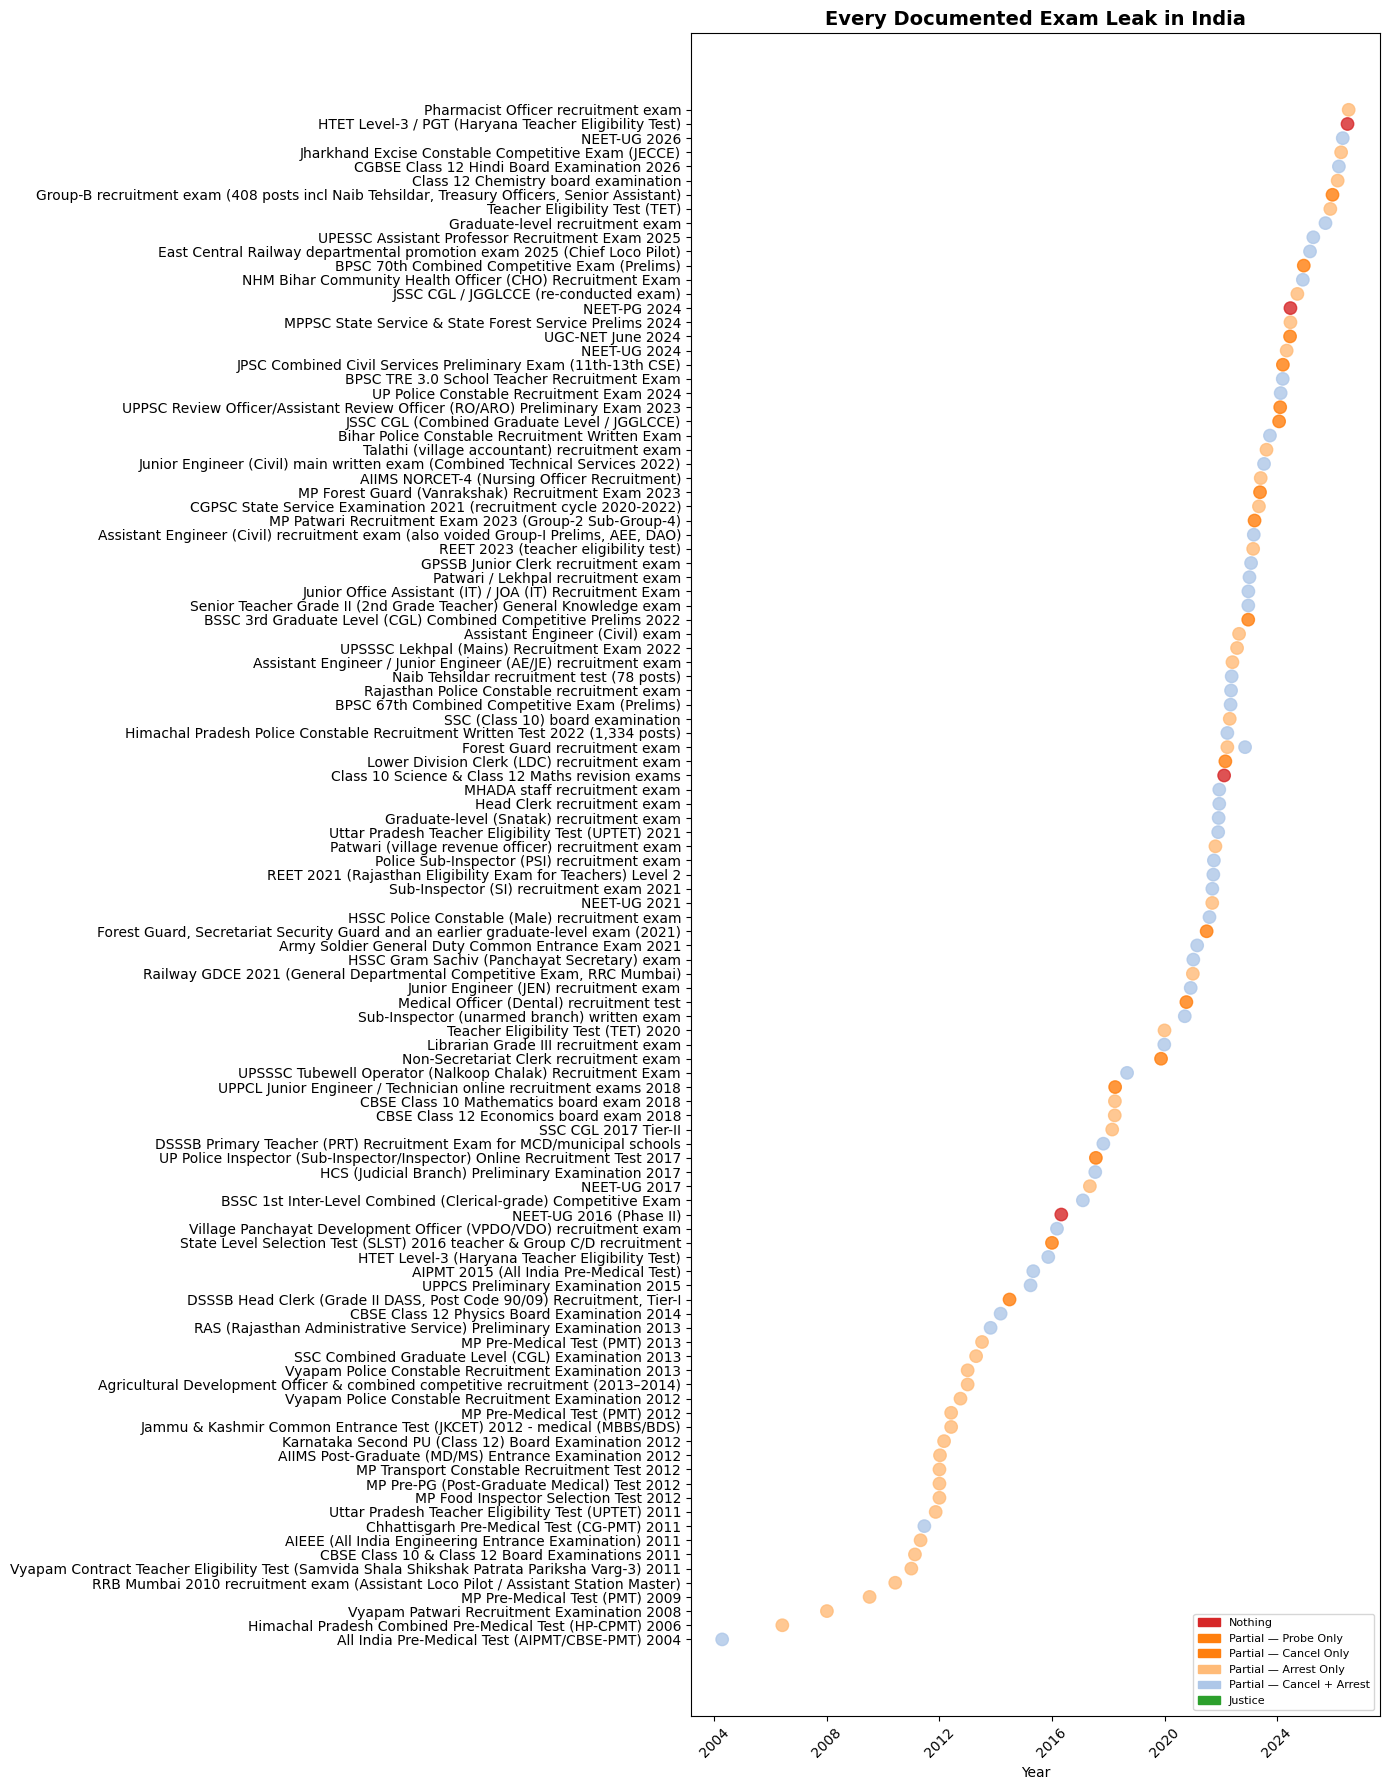

In [2]:
color_map = {
    'Nothing': '#d62728',
    'Partial — Probe Only': '#ff7f0e',
    'Partial — Cancel Only': '#ff7f0e',
    'Partial — Arrest Only': '#ffbb78',
    'Partial — Cancel + Arrest': '#aec7e8',
    'Justice': '#2ca02c'
}

colors = df['action_clean'].map(color_map)

plt.figure(figsize=(14, 18))
plt.scatter(df['date'], df['exam_name'], c=colors, s=80, alpha=0.8)
plt.title('Every Documented Exam Leak in India', fontsize=14, fontweight='bold')
plt.xlabel('Year')
plt.ylabel('')
plt.xticks(rotation=45)
plt.tight_layout()

# legend
patches = [mpatches.Patch(color=v, label=k) for k, v in color_map.items()]
plt.legend(handles=patches, loc='lower right', fontsize=8)

plt.savefig('charts/chart1_timeline.png', dpi=150, bbox_inches='tight')
plt.show()

# 02. Funnel

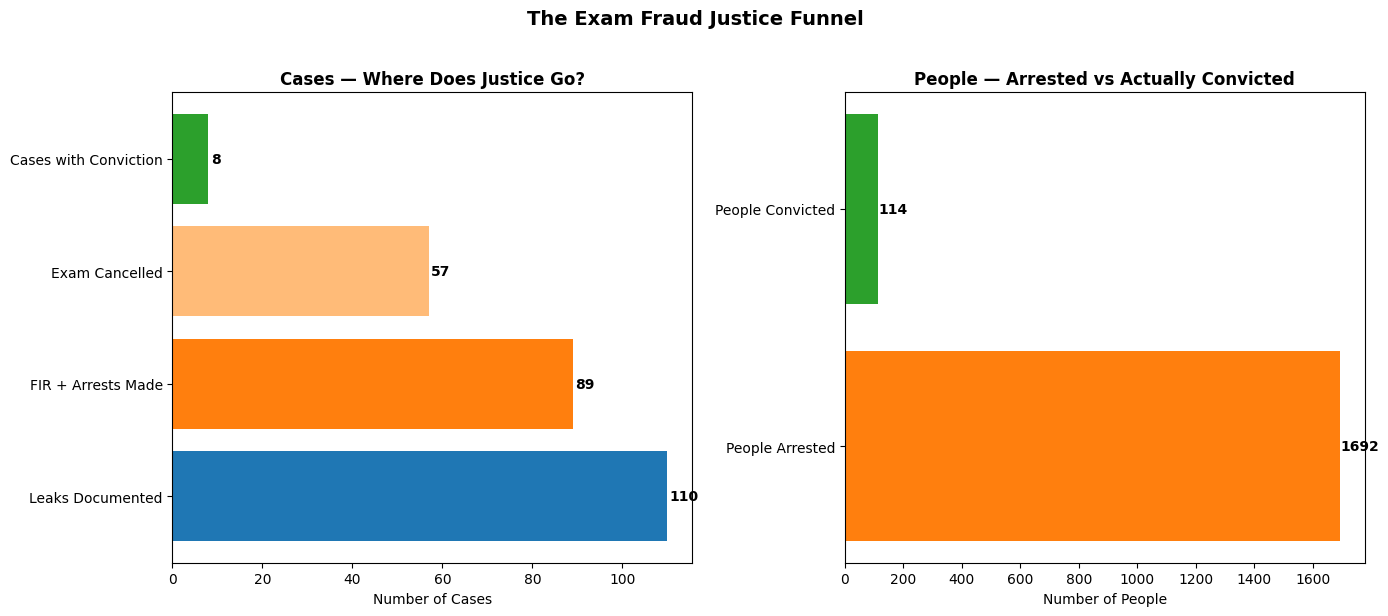

In [3]:
total = len(df)
had_fir = len(df[df['action_clean'].str.contains('Arrest', na=False)])
had_cancel = len(df[df['action_clean'].str.contains('Cancel', na=False)])
had_conviction_cases = len(df[df['convictions_filled'] > 0])  # 8 cases
had_conviction_people = int(df['convictions_filled'].sum())    # 114 people

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# ── left: case funnel ─────────────────────────────────────
stages = ['Leaks Documented', 'FIR + Arrests Made', 'Exam Cancelled', 'Cases with Conviction']
values = [total, had_fir, had_cancel, had_conviction_cases]

bars1 = axes[0].barh(stages, values, color=['#1f77b4', '#ff7f0e', '#ffbb78', '#2ca02c'])
axes[0].set_xlabel('Number of Cases')
axes[0].set_title('Cases — Where Does Justice Go?', fontsize=12, fontweight='bold')

for bar, val in zip(bars1, values):
    axes[0].text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
                 str(val), va='center', fontweight='bold')

# ── right: people convicted vs people arrested ────────────
labels = ['People Arrested', 'People Convicted']
people_values = [int(df['arrests_filled'].sum()), had_conviction_people]

bars2 = axes[1].barh(labels, people_values, color=['#ff7f0e', '#2ca02c'])
axes[1].set_xlabel('Number of People')
axes[1].set_title('People — Arrested vs Actually Convicted', fontsize=12, fontweight='bold')

for bar, val in zip(bars2, people_values):
    axes[1].text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
                 str(val), va='center', fontweight='bold')

plt.suptitle('The Exam Fraud Justice Funnel', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('charts/chart2_funnel.png', dpi=150, bbox_inches='tight')
plt.show()

# 03. UPA vs NDA

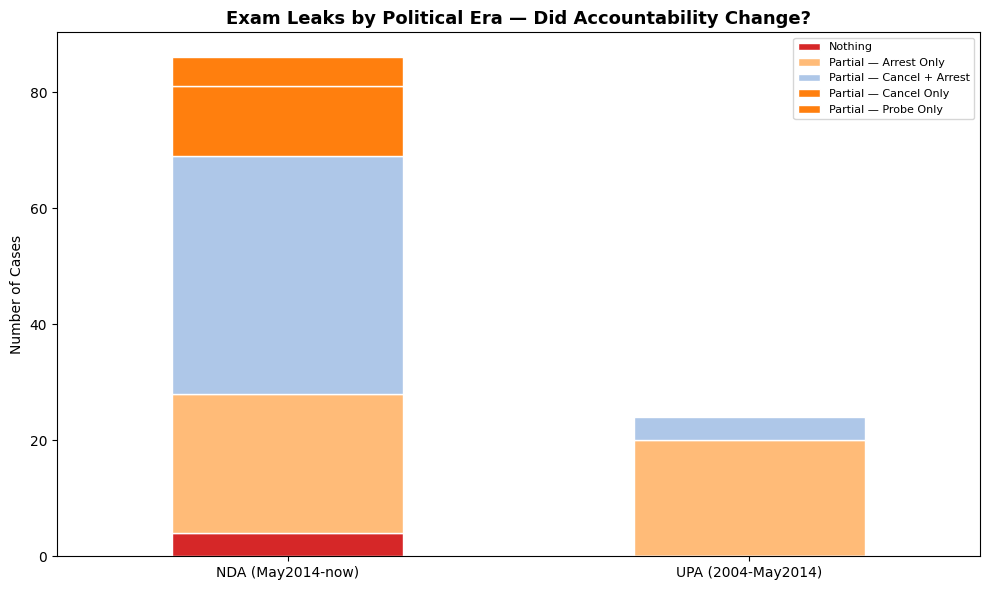

In [4]:
era_action = df.groupby(['era', 'action_clean']).size().unstack(fill_value=0)

era_action.plot(
    kind='bar',
    figsize=(10, 6),
    color=[color_map.get(c, '#999999') for c in era_action.columns],
    stacked=True,
    edgecolor='white'
)

plt.title('Exam Leaks by Political Era — Did Accountability Change?', fontsize=13, fontweight='bold')
plt.xlabel('')
plt.ylabel('Number of Cases')
plt.xticks(rotation=0)
plt.legend(loc='upper right', fontsize=8)
plt.tight_layout()
plt.savefig('charts/chart3_era.png', dpi=150, bbox_inches='tight')
plt.show()

# 04. State Bar

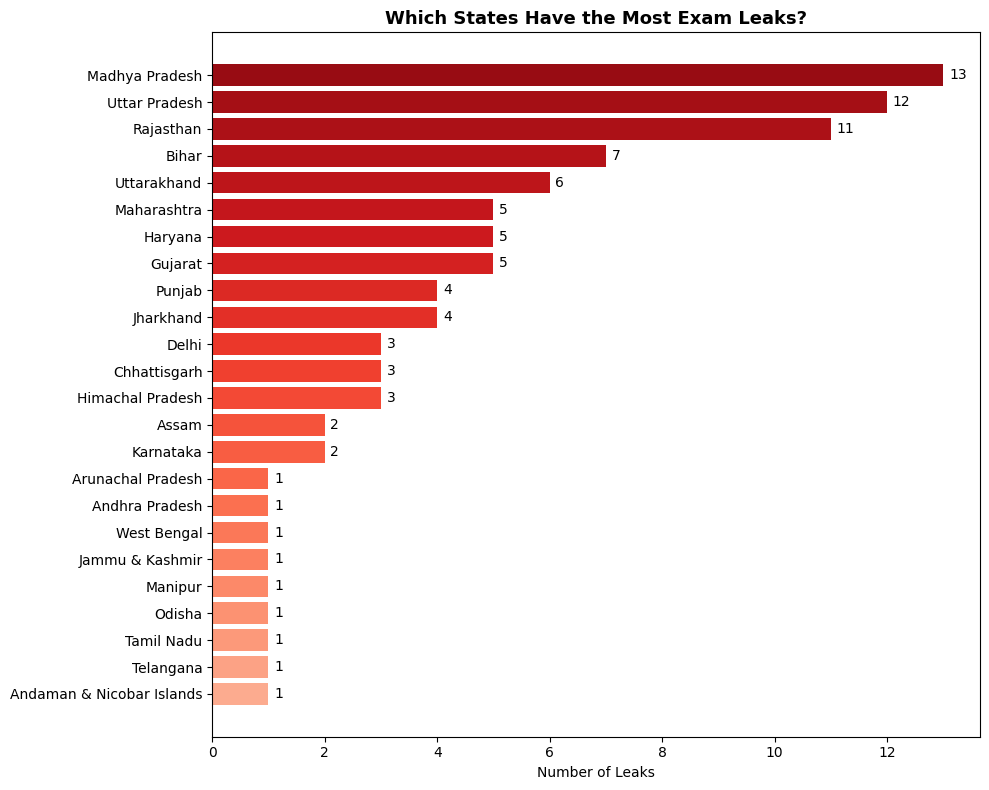

In [5]:
state_counts = df[df['state'] != 'All India'].groupby('state').size().sort_values()

plt.figure(figsize=(10, 8))
bars = plt.barh(state_counts.index, state_counts.values,
                color=plt.cm.Reds(np.linspace(0.3, 0.9, len(state_counts))))

plt.title('Which States Have the Most Exam Leaks?', fontsize=13, fontweight='bold')
plt.xlabel('Number of Leaks')
plt.ylabel('')

for bar, val in zip(bars, state_counts.values):
    plt.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
             str(val), va='center')

plt.tight_layout()
plt.savefig('charts/chart4_states.png', dpi=150, bbox_inches='tight')
plt.show()

# 05. Leak Status

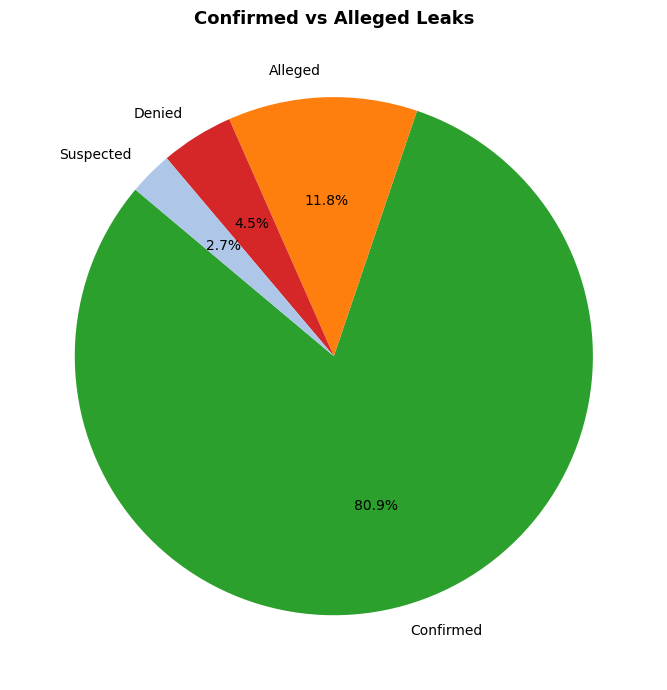

In [6]:
status_counts = df['leak_status'].value_counts()

plt.figure(figsize=(7, 7))
plt.pie(
    status_counts.values,
    labels=status_counts.index,
    autopct='%1.1f%%',
    colors=['#2ca02c', '#ff7f0e', '#d62728', '#aec7e8'],
    startangle=140
)
plt.title('Confirmed vs Alleged Leaks', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('charts/chart5_status.png', dpi=150, bbox_inches='tight')
plt.show()

# 06. Actual convictions

In [7]:
# see exactly which rows have convictions
print(df[df['convictions_filled'] > 0][['exam_name', 'area', 'convictions', 'convictions_filled', 'note']])

                                            exam_name  \
2         Vyapam Patwari Recruitment Examination 2008   
4   RRB Mumbai 2010 recruitment exam (Assistant Lo...   
6    CBSE Class 10 & Class 12 Board Examinations 2011   
15  Jammu & Kashmir Common Entrance Test (JKCET) 2...   
17  Vyapam Police Constable Recruitment Examinatio...   
18  Agricultural Development Officer & combined co...   
19  Vyapam Police Constable Recruitment Examinatio...   
33  HCS (Judicial Branch) Preliminary Examination ...   

                         area  convictions  convictions_filled  \
2              Madhya Pradesh         10.0                10.0   
4                   All India         10.0                10.0   
6   Andaman & Nicobar Islands          4.0                 4.0   
15            Jammu & Kashmir         11.0                11.0   
17             Madhya Pradesh         11.0                11.0   
18                      Assam         34.0                34.0   
19             Madhya Pr

# 07. Conviction distribution

In [8]:
# check conviction distribution by era
print(df.groupby('era')['convictions_filled'].sum())
print()

# check conviction distribution by year
df['year'] = pd.to_datetime(df['date']).dt.year
print(df.groupby('year')['convictions_filled'].sum().sort_index())

era
NDA (May2014-now)       3.0
UPA (2004-May2014)    111.0
Name: convictions_filled, dtype: float64

year
2004     0.0
2006     0.0
2008    10.0
2009     0.0
2010    10.0
2011     4.0
2012    22.0
2013    65.0
2014     0.0
2015     0.0
2016     0.0
2017     3.0
2018     0.0
2019     0.0
2020     0.0
2021     0.0
2022     0.0
2023     0.0
2024     0.0
2025     0.0
2026     0.0
Name: convictions_filled, dtype: float64


# 08. Convictions by year

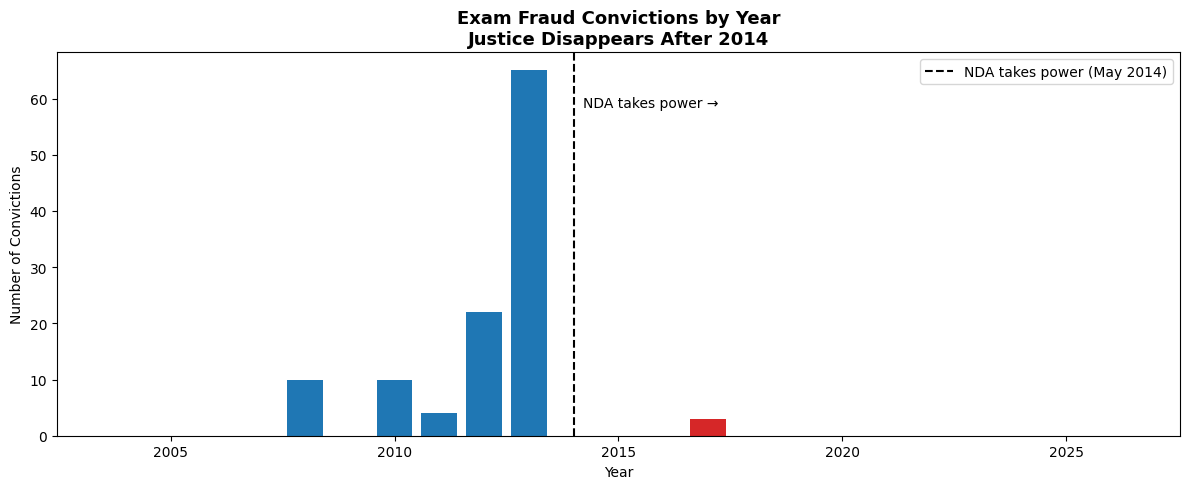

In [9]:
yearly = df.groupby('year')['convictions_filled'].sum().reset_index()

plt.figure(figsize=(12, 5))
bars = plt.bar(yearly['year'], yearly['convictions_filled'],
               color=['#d62728' if y >= 2014 else '#1f77b4' for y in yearly['year']])

plt.axvline(x=2014, color='black', linestyle='--', linewidth=1.5, label='NDA takes power (May 2014)')
plt.text(2014.2, yearly['convictions_filled'].max() * 0.9,
         'NDA takes power →', fontsize=10, color='black')

plt.title('Exam Fraud Convictions by Year\nJustice Disappears After 2014',
          fontsize=13, fontweight='bold')
plt.xlabel('Year')
plt.ylabel('Number of Convictions')
plt.legend()
plt.tight_layout()
plt.savefig('charts/chart6_convictions_by_year.png', dpi=150, bbox_inches='tight')
plt.show()

# 09. Era Comparisons

                    convictions_filled  total_leaks  conviction_rate_pct
era                                                                     
NDA (May2014-now)                  3.0           86                  3.5
UPA (2004-May2014)               111.0           24                462.5


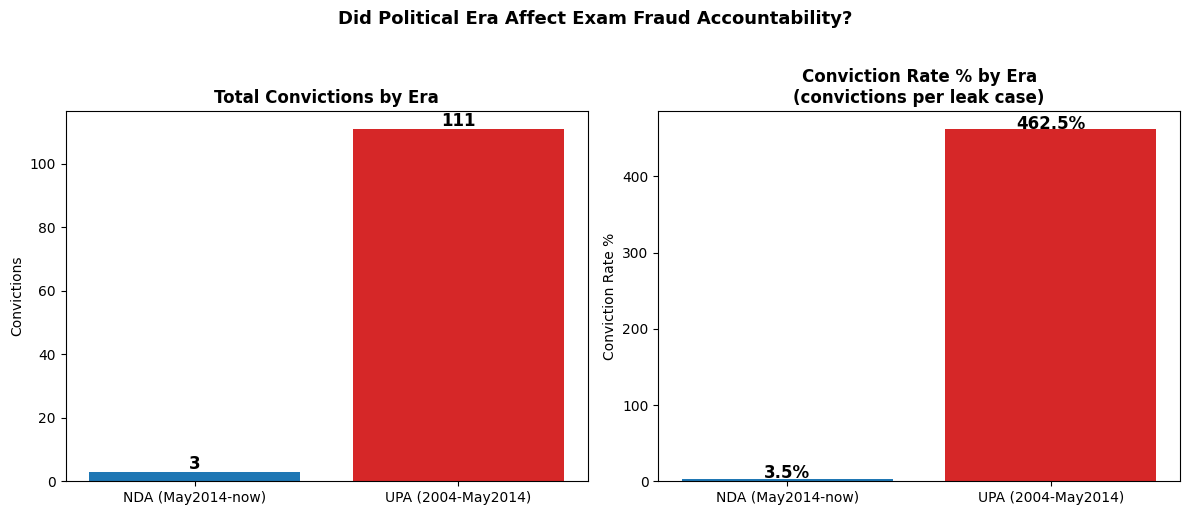

In [10]:
era_conv = df.groupby('era')[['convictions_filled']].sum()
era_leaks = df.groupby('era').size().rename('total_leaks')
era_summary = pd.concat([era_conv, era_leaks], axis=1)
era_summary['conviction_rate_pct'] = (era_summary['convictions_filled'] / era_summary['total_leaks'] * 100).round(1)
print(era_summary)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# left — total convictions
axes[0].bar(era_summary.index, era_summary['convictions_filled'],
            color=['#1f77b4', '#d62728'])
axes[0].set_title('Total Convictions by Era', fontweight='bold')
axes[0].set_ylabel('Convictions')
for i, (idx, row) in enumerate(era_summary.iterrows()):
    axes[0].text(i, row['convictions_filled'] + 1, str(int(row['convictions_filled'])),
                 ha='center', fontweight='bold', fontsize=12)

# right — conviction rate
axes[1].bar(era_summary.index, era_summary['conviction_rate_pct'],
            color=['#1f77b4', '#d62728'])
axes[1].set_title('Conviction Rate % by Era\n(convictions per leak case)', fontweight='bold')
axes[1].set_ylabel('Conviction Rate %')
for i, (idx, row) in enumerate(era_summary.iterrows()):
    axes[1].text(i, row['conviction_rate_pct'] + 0.2, f"{row['conviction_rate_pct']}%",
                 ha='center', fontweight='bold', fontsize=12)

plt.suptitle('Did Political Era Affect Exam Fraud Accountability?',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('charts/chart7_era_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# 10. Conviction details

In [11]:
# print full details of every row with convictions
conviction_rows = df[df['convictions_filled'] > 0][
    ['exam_name', 'year', 'area', 'convictions', 'note', 'source_url', 'confidence']
]

for _, row in conviction_rows.iterrows():
    print("="*60)
    print(f"EXAM: {row['exam_name']}")
    print(f"YEAR: {row['year']}")
    print(f"AREA: {row['area']}")
    print(f"CONVICTIONS: {row['convictions']}")
    print(f"CONFIDENCE: {row['confidence']}")
    print(f"NOTE: {row['note']}")
    print(f"SOURCE: {row['source_url']}")
    print()

EXAM: Vyapam Patwari Recruitment Examination 2008
YEAR: 2008
AREA: Madhya Pradesh
CONVICTIONS: 10.0
CONFIDENCE: High
NOTE: Accused produced forged educational certificates to fake eligibility and secure patwari posts; CBI court sentenced 10 to 5 years RI each (Dec 2025). Only year of exam known, Jan placeholder.
SOURCE: https://the420.in/vyapam-scam-cbi-court-patwari-exam-fraud-10-convicts-sentenced/

EXAM: RRB Mumbai 2010 recruitment exam (Assistant Loco Pilot / Assistant Station Master)
YEAR: 2010
AREA: All India
CONVICTIONS: 10.0
CONFIDENCE: High
NOTE: CBI registered a case on 15 June 2010 over the leak of question papers for recruitment to 1,936 assistant loco pilot/station master posts (exam scheduled 6 June 2010); in Jan 2024 a CBI special court convicted 10, including the former RRB-Mumbai chairman, to five years RI, with 4 acquitted. Date is the scheduled exam date; day known.
SOURCE: https://www.theweek.in/wire-updates/national/2024/01/30/del90-cbi-railways.html

EXAM: CBSE Cl

# 11. Time Taken To Justice

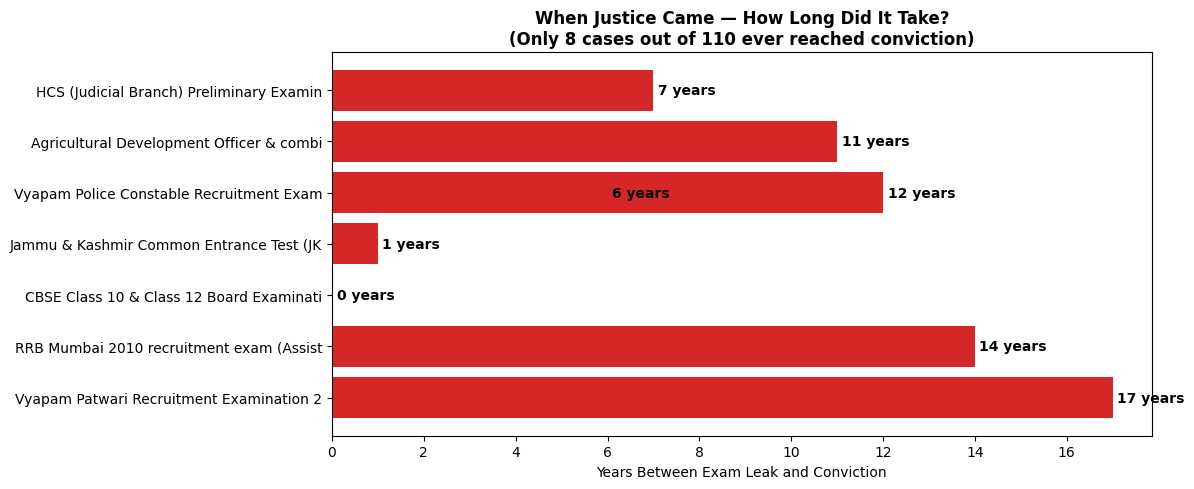


Average years to justice: 8.5 years
Maximum wait: 17 years


In [12]:
# time to justice — years between exam and conviction
conviction_rows = df[df['convictions_filled'] > 0].copy()
conviction_rows['year'] = pd.to_datetime(conviction_rows['date']).dt.year

# manually add conviction year based on what we just read
conviction_years = {
    'Vyapam Patwari Recruitment Examination 2008': 2025,
    'RRB Mumbai 2010 recruitment exam (Assistant Loco Pilot / Assistant Station Master)': 2024,
    'CBSE Class 10 & Class 12 Board Examinations 2011': 2011,
    'Jammu & Kashmir Common Entrance Test (JKCET) 2012 - medical (MBBS/BDS)': 2013,
    'Vyapam Police Constable Recruitment Examination 2012': 2024,
    'Agricultural Development Officer & combined competitive recruitment (2013–2014)': 2024,
    'Vyapam Police Constable Recruitment Examination 2013': 2019,
    'HCS (Judicial Branch) Preliminary Examination 2017': 2024,
}

conviction_rows['conviction_year'] = conviction_rows['exam_name'].map(conviction_years)
conviction_rows['years_to_justice'] = conviction_rows['conviction_year'] - conviction_rows['year']

plt.figure(figsize=(12, 5))
bars = plt.barh(
    conviction_rows['exam_name'].str[:40],  # truncate long names
    conviction_rows['years_to_justice'],
    color='#d62728'
)

for bar, val in zip(bars, conviction_rows['years_to_justice']):
    plt.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
             f'{int(val)} years', va='center', fontweight='bold')

plt.xlabel('Years Between Exam Leak and Conviction')
plt.title('When Justice Came — How Long Did It Take?\n(Only 8 cases out of 110 ever reached conviction)',
          fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('charts/chart8_time_to_justice.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nAverage years to justice: {conviction_rows['years_to_justice'].mean():.1f} years")
print(f"Maximum wait: {conviction_rows['years_to_justice'].max()} years")

# 12. Findings

In [13]:
total = len(df)
convicted_cases = len(df[df['convictions_filled'] > 0])
zero_justice = total - convicted_cases
avg_wait = 8.5
affected = df['aspirants_affected'].sum()

print("=" * 50)
print("THE COMPLETE PICTURE — EXAM FRAUD IN INDIA")
print("=" * 50)
print(f"Total documented leaks:         {total}")
print(f"Cases with ANY conviction:      {convicted_cases} ({convicted_cases/total*100:.1f}%)")
print(f"Cases with ZERO conviction:     {zero_justice} ({zero_justice/total*100:.1f}%)")
print(f"Average wait for justice:       {avg_wait} years")
print(f"Maximum wait for justice:       17 years")
print(f"Total aspirants affected:       {int(affected):,}")
print(f"Convictions under NDA (2014+):  3")
print(f"Convictions under UPA (2004-14): 111")
print("=" * 50)

THE COMPLETE PICTURE — EXAM FRAUD IN INDIA
Total documented leaks:         110
Cases with ANY conviction:      8 (7.3%)
Cases with ZERO conviction:     102 (92.7%)
Average wait for justice:       8.5 years
Maximum wait for justice:       17 years
Total aspirants affected:       22,511,568
Convictions under NDA (2014+):  3
Convictions under UPA (2004-14): 111
